# KOSHA 안전보건 Visual RAG: ColPali + Qdrant + Qwen3-VL

[KOSHA 산업안전보건공단 산업안전보건 자료](https://portal.kosha.or.kr/archive/cent-archive/indust-arch/indust-page1/indust-page1-list1?page=1&rowsPerPage=12)의 PDF 매뉴얼(`KOSHA_Safety_Health.zip`)로
**문서 페이지 Visual RAG** 파이프라인을 단계별로 구현합니다.

## 전체 흐름

```
PDF (KOSHA 안전보건 자료)
       ↓
페이지를 이미지로 변환 (PyMuPDF)
       ↓
ColPali Multi-vector 임베딩
       ↓
Qdrant (Multi-vector, MaxSim)
       ↓
질문 (한글)
       ↓
관련 페이지 검색
       ↓
Qwen3-VL 답변 생성
```

| 단계 | 역할 |
|------|------|
| **PyMuPDF** | PDF 각 페이지를 PNG/JPG 이미지로 렌더링 |
| **ColPali** | 페이지 이미지·질문을 Late Interaction Multi-vector로 임베딩 |
| **Qdrant** | Multi-vector 저장·MaxSim 유사도 검색 |
| **Qwen3-VL** | 검색된 페이지 이미지를 근거로 한글 답변 생성 |

### Visual RAG란?

- **RAG(Retrieval-Augmented Generation)**: 질문에 맞는 자료를 먼저 **검색**하고, 그 내용을 AI 생성 모델에 넣어 **근거 있는 답변**을 만드는 방식입니다.
- **Visual RAG**: 검색 대상이 일반 텍스트 파일이 아니라 **이미지(또는 PDF 페이지 스크린샷)** 인 RAG입니다.
- 이 노트북은 **검색(Retriever: ColPali + Qdrant)** 과 **생성(Generator: Qwen3-VL)** 을 분리합니다.
  - 검색은 빠르게 관련 페이지를 찾고, 생성은 그 페이지를 읽어 상세 답변을 작성합니다.

### 왜 PDF를 OCR 없이 이미지로 검색하나?

산업 안전 매뉴얼 PDF에는 **표, 도표, 박스 레이아웃, 경고 아이콘**이 많습니다.
전통적인 방식(OCR → 텍스트 추출 → 청크 분할)은 표 구조·시각적 강조를 잃기 쉽습니다.

**ColPali**는 PDF 페이지를 **통째로 이미지**로 보고, 글자·표·그림·배치를 함께 이해하는 검색 모델입니다.
OCR 전처리 없이도 "지게차 충돌 예방" 같은 질문에 맞는 **페이지 전체**를 찾을 수 있습니다.

### 02·11번 노트북과의 차이

| 구분 | 02·11번 (설비·CCTV) | 12번 (KOSHA PDF) |
|------|---------------------|------------------|
| 데이터 | 영상 프레임·CCTV | PDF 안전 매뉴얼 |
| 임베딩 | SigLIP2 (단일 벡터) | ColPali (Multi-vector) |
| 벡터 DB | ChromaDB | Qdrant (MaxSim) |
| 검색 단위 | 프레임 1장 | PDF 페이지 1장 |


### 모듈·데이터 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 구성요소 | 경로 |
|----------|------|
| KOSHA 데이터셋 | `KOSHA_Safety_Health.zip` → `data/kosha/pdfs/` |
| 페이지 이미지 | `data/kosha/pages/` |
| Qdrant DB | `data/kosha/qdrant_db/` |
| 한글 차트 | `conveyor_analyze/conveyor_rag/plot_utils.py` |

**폴더 역할 요약**

- `pdfs/` — ZIP에서 풀린 원본 PDF (한글 파일명)
- `pages/` — PDF 각 페이지를 PNG로 저장 (`doc_해시/page_0001.png` 형식)
- `pages_manifest.json` — 페이지별 PDF 이름·경로·페이지 번호 목록
- `qdrant_db/` — ColPali Multi-vector가 저장된 로컬 벡터 DB


## 0. 환경 설정

이 단계에서는 라이브러리를 불러오고, 데이터 경로·모델 이름·GPU 여부·실습 규모 옵션을 설정합니다.

| 기술 | 설명 |
|------|------|
| **PyMuPDF (`fitz`)** | PDF 파일을 열어 각 페이지를 PNG 이미지로 렌더링 |
| **ColPali (transformers)** | `vidore/colpali-v1.3-hf` — PDF 페이지·질문 Multi-vector 임베딩 |
| **Qdrant** | 로컬 디스크에 Multi-vector를 저장하고 MaxSim 유사도로 검색 |
| **Qwen3-VL** | 검색된 페이지 이미지 + 질문 → 한글 답변 생성 (Vision Language Model) |
| **PyTorch** | ColPali·Qwen3-VL GPU 추론. `device=cuda`이면 GPU 가속 |
| **transformers** | Hugging Face에서 ColPali·Qwen3-VL 모델 로드 |

**사전 준비**
<br>
1. KOSHA 포털 또는 프로젝트 루트에 `KOSHA_Safety_Health.zip` 배치<br>
2. GPU 권장 (ColPali + Qwen3-VL). CPU도 가능하나 속도가 매우 느립니다.<br>
3. 첫 실행 시 Hugging Face에서 모델 가중치를 다운로드합니다 (ColPali ~6GB, Qwen3-VL ~4GB).

> **데모 모드**: `DEMO_MODE = True`이면 PDF 5개·페이지당 5장만 인덱싱합니다.
> 전체 40개 PDF를 쓰려면 `DEMO_MODE = False`, `MAX_PAGES_PER_PDF = None`으로 변경하세요.

### 주요 설정 변수

| 변수 | 의미 | 초보자 팁 |
|------|------|-----------|
| `DEMO_MODE` | 소량 PDF만 사용 | 처음 실행·GPU 메모리 부족 시 `True` |
| `MAX_PAGES_PER_PDF` | PDF당 인덱싱할 최대 페이지 | `None`이면 전체 페이지 |
| `REBUILD_INDEX` | Qdrant·manifest 재생성 | PDF·이미지 바꿨으면 `True` |
| `TOP_K` | 검색·답변에 쓸 페이지 수 | 3~5가 적당 |
| `COLPALI_BATCH_SIZE` | 한 번에 임베딩할 페이지 수 | OOM 나면 `1`로 줄이기 |


In [25]:
# 모듈 전체 설치시 : Colab에서 아래 주석문 해제후 실행 --> Kernel Restart
# !pip install qdrant-client pymupdf transformers accelerate torch pillow tqdm qwen-vl-utils

# Colab :  KOSHA_Safety_Health.zip 압축 파일미리 업로드 필요

# 일부 설치시
# !py -3.11 -m pip install qdrant-client pymupdf qwen-vl-utils
# ColPali·Qwen3-VL은 transformers/torch가 이미 있으면 위 3개만 추가 설치해도 됩니다.


In [24]:
# Colab : conveyor_analyze.zip 압축파일 미리 업로드 후 여기서 압축 해제
# !unzip conveyor_analyze.zip -d conveyor_analyze

In [10]:
import gc         # GPU 모델 해제 후 메모리 정리
import hashlib    # PDF 경로 → doc_id 해시
import json       # pages_manifest.json 저장·로드
import shutil     # ZIP 추출·폴더 삭제
import sys        # conveyor_analyze 모듈 path 등록
import uuid       # Qdrant 포인트 ID (UUID5)
import zipfile    # KOSHA_Safety_Health.zip 해제
from pathlib import Path  # OS 독립적 경로 처리

import fitz  # PyMuPDF — PDF 페이지 → PNG 렌더링
import matplotlib.pyplot as plt       # 검색 결과 페이지 미리보기
import numpy as np
import pandas as pd       # manifest·검색 결과 테이블
import torch              # ColPali·Qwen3-VL GPU 추론
from IPython.display import Markdown, display  # 답변·DataFrame 출력
from PIL import Image     # 페이지 이미지 로드 (RGB)
from qdrant_client import QdrantClient, models  # Multi-vector 벡터 DB
from tqdm.auto import tqdm     # PDF 변환·인덱싱 진행률
from transformers import AutoProcessor, ColPaliForRetrieval, ColPaliProcessor, Qwen3VLForConditionalGeneration

# --- 경로 (노트북 실행 위치 = 프로젝트 루트) ---
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "kosha"
PDF_DIR = DATA_DIR / "pdfs"              # ZIP에서 추출한 PDF
PAGES_DIR = DATA_DIR / "pages"           # PDF → PNG 페이지 이미지
QDRANT_DIR = DATA_DIR / "qdrant_db"      # Qdrant 로컬 Persistent 저장
MANIFEST_PATH = DATA_DIR / "pages_manifest.json"  # 페이지 메타(JSON)
ZIP_PATH = ROOT / "KOSHA_Safety_Health.zip"

# matplotlib 한글 폰트 (02 노트북과 동일 모듈)
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
sys.path.insert(0, str(CONVEYOR_ANALYZE))
from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

# --- 모델·벡터 DB 설정 ---
COLPALI_MODEL_ID = "vidore/colpali-v1.3-hf"   # PDF 페이지 Multi-vector 검색
QWEN_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"   # 검색 페이지 기반 VQA
COLLECTION_NAME = "kosha_colpali_pages"       # Qdrant 컬렉션명
VECTOR_NAME = "colpali"                       # Multi-vector 필드명
EMBED_DIM = 128                               # ColPali 패치 벡터 차원

# --- 실습 규모 조절 ---
DEMO_MODE = False         # False → ZIP 내 전체 PDF 인덱싱
DEMO_PDF_LIMIT = 5        # DEMO_MODE일 때 PDF 개수
MAX_PAGES_PER_PDF = 5     # PDF당 최대 페이지 (None = 전체)
PDF_DPI = 150             # 렌더 해상도
COLPALI_BATCH_SIZE = 2    # GPU OOM 시 1로 줄이기
TOP_K = 3                 # 검색·VLM에 사용할 상위 페이지 수
REBUILD_INDEX = True      # True면 Qdrant 컬렉션 재구축

device = "cuda" if torch.cuda.is_available() else "cpu"

# 아래 두 변수는 셀 재실행 시 싱글톤·지연 로딩에 사용
colpali_encoder = None
qdrant_client = None   # Qdrant 로컬 DB는 커널당 1개 클라이언트만 허용

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"{ZIP_PATH} 없음. KOSHA 포털에서 다운로드 후 프로젝트 루트에 배치하세요."
    )

# 데이터·벡터 DB 저장 폴더 생성
for d in (PDF_DIR, PAGES_DIR, QDRANT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Device: {device}")
print(f"ZIP: {ZIP_PATH} (존재)")
print(f"ColPali: {COLPALI_MODEL_ID}")
print(f"Qwen: {QWEN_MODEL_ID}")
print(f"DEMO_MODE={DEMO_MODE}, PDF limit={DEMO_PDF_LIMIT}, pages/PDF={MAX_PAGES_PER_PDF}")
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")


ROOT: /content
Device: cuda
ZIP: /content/KOSHA_Safety_Health.zip (존재)
ColPali: vidore/colpali-v1.3-hf
Qwen: Qwen/Qwen3-VL-2B-Instruct
DEMO_MODE=False, PDF limit=5, pages/PDF=5
matplotlib 한글 폰트: NanumGothic


## 1. KOSHA ZIP 압축 해제

`KOSHA_Safety_Health.zip`에는 산업안전보건 관련 PDF 약 **40개**가 포함됩니다.
(크레인, 전기설비, 화학물질, 지게차, 밀폐공간, 용접·도장, 컨베이어 키메시지 등)

### 이 단계에서 하는 일

1. ZIP 파일 목록에서 `.pdf`만 골라 `data/kosha/pdfs/`에 저장
2. Windows CP949로 저장된 **한글 파일명**을 올바르게 복원
3. 이미 추출됐지만 파일명이 깨져 있으면 폴더를 비우고 다시 추출

### 왜 파일명 복원이 필요한가?

KOSHA ZIP은 Windows에서 만들어져 파일명이 **CP949(한글)** 인코딩입니다.
Python `zipfile`은 기본적으로 UTF-8로 읽으려 해 `[2025-▒│└░...]`처럼 **깨진 이름**으로 저장될 수 있습니다.

`decode_zip_filename()`은 `cp437 → cp949` 변환으로
`[2026-산업안전실-219]28. 지게차 사용 작업.pdf`처럼 **정상 한글 이름**으로 복원합니다.

### 데이터셋 예시 (일부)

| PDF 주제 | 예시 질의 |
|----------|-----------|
| 지게차 사용 작업 | "충돌·전도 예방 조치는?" |
| 전기설비 취급 | "감전 예방 조치는?" |
| 밀폐공간 작업 | "산소결핍 예방은?" |
| 키메시지(컨베이어) | "끼임·협착 예방 수칙은?" |


In [11]:
def decode_zip_filename(name: str) -> str:
    """Windows CP949 ZIP 엔트리명 → UTF-8 한글 파일명 복원."""
    if name.isascii():
        return name
    # 이미 정상 한글이면 그대로 반환
    if not any(ch in name for ch in "▒└┐¡╟⌡═"):
        return name
    # Python zipfile은 CP949 파일명을 cp437 유니코드로 잘못 디코딩함 → cp949로 재해석
    for encoding in ("cp949", "euc-kr"):
        try:
            return name.encode("cp437").decode(encoding)
        except (UnicodeDecodeError, UnicodeEncodeError):
            continue
    return name


def is_broken_korean_filename(name: str) -> bool:
    """ZIP CP949를 UTF-8로 잘못 읽어 깨진 파일명 여부."""
    return any(ch in name for ch in "▒└┐¡╟⌡═")


def extract_kosha_zip(zip_path: Path, dest: Path, pdf_limit: int | None = None) -> list[Path]:
    """ZIP에서 PDF를 dest로 추출. CP949 파일명을 한글로 복원해 저장."""
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        # 복원된 한글 이름 기준 정렬 → DEMO_MODE에서도 일관된 PDF 선택
        pdf_names = sorted(
            (n for n in zf.namelist() if decode_zip_filename(n).lower().endswith(".pdf")),
            key=lambda n: decode_zip_filename(n),
        )
        if pdf_limit:
            pdf_names = pdf_names[:pdf_limit]

        extracted = []
        for raw_name in pdf_names:
            fixed_name = decode_zip_filename(raw_name)
            out_path = dest / fixed_name
            out_path.parent.mkdir(parents=True, exist_ok=True)
            # zf.extract()는 깨진 raw_name으로 저장하므로, 복원 이름으로 직접 쓰기
            with zf.open(raw_name) as src, open(out_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            extracted.append(out_path)
    return extracted


# 이미 추출된 PDF가 있는지, 파일명이 깨졌는지 확인
existing_pdfs = sorted(PDF_DIR.rglob("*.pdf"))
need_extract = not existing_pdfs or any(is_broken_korean_filename(p.name) for p in existing_pdfs)

if need_extract:
    if existing_pdfs:
        print("깨진 파일명 PDF 감지 → pdfs/ 폴더를 비우고 다시 추출합니다.")
        shutil.rmtree(PDF_DIR)
        PDF_DIR.mkdir(parents=True, exist_ok=True)
    limit = DEMO_PDF_LIMIT if DEMO_MODE else None
    pdfs = extract_kosha_zip(ZIP_PATH, PDF_DIR, pdf_limit=limit)
    print(f"PDF 추출 완료: {len(pdfs)}개")
else:
    pdfs = existing_pdfs
    if DEMO_MODE:
        pdfs = pdfs[:DEMO_PDF_LIMIT]
    print(f"기존 PDF 사용: {len(pdfs)}개")

# 추출된 PDF 목록 일부 출력
for i, p in enumerate(pdfs[:5], 1):
    print(f"  {i}. {p.name}")
if len(pdfs) > 5:
    print(f"  ... 외 {len(pdfs) - 5}개")


PDF 추출 완료: 41개
  1. [2025-교육혁신실-2116]열교환기 기압시험 중 플랜지에 맞음(웹용).pdf
  2. [2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf
  3. [2026-교육총괄실-15]키메시지(1호_컨베이어).pdf
  4. [2026-교육총괄실-276]키메시지(6호_화재·폭발).pdf
  5. [2026-교육총괄실-84]키메시지(3호_깔림·뒤집힘).pdf
  ... 외 36개


## 2. PDF → 페이지 이미지 변환

PyMuPDF로 각 PDF 페이지를 **PNG 이미지**로 렌더링합니다.
OCR 전처리 없이 **페이지 전체 스크린샷**을 ColPali 입력으로 사용합니다.

### PyMuPDF란?

- PDF를 읽고 **페이지 단위로 비트맵(픽셀)** 으로 그려 주는 라이브러리입니다.
- Word·한글에서 "PDF로 저장"한 문서, 스캔 PDF 모두 처리 가능합니다.
- OCR과 달리 **글자를 텍스트로 추출하지 않고**, 사람이 화면에서 보는 것과 같은 **그림**을 만듭니다.

### 왜 페이지 이미지로 저장하나?

ColPali는 **이미지 입력** 전용 검색 모델입니다.
PDF 파일을 직접 넣을 수 없으므로, 각 페이지를 PNG로 바꿔 `data/kosha/pages/`에 저장합니다.

```
data/kosha/pages/
  doc_a1b2c3d4e5/
    page_0001.png   ← PDF 1페이지
    page_0002.png   ← PDF 2페이지
```

### manifest(JSON)란?

`pages_manifest.json`은 **페이지 목록 카탈로그**입니다.
각 레코드에 PDF 이름, 페이지 번호, 이미지 경로가 들어 있어
나중에 Qdrant 검색 결과 → 원본 PDF·페이지를 역추적할 수 있습니다.

| 필드 | 의미 |
|------|------|
| `doc_id` | PDF별 고유 ID (파일명 해시) |
| `pdf_name` | 원본 PDF 한글 파일명 |
| `page_num` | 몇 페이지인지 (1부터) |
| `image_path` | PNG 파일 절대 경로 |

### DPI(`PDF_DPI`) 설정

- **150 DPI** — 실습용 기본값. 속도와 화질 균형
- 높이면 표·작은 글씨가 선명하지만 ColPali 임베딩·디스크 용량 증가
- 낮추면 빠르지만 검색 정확도가 떨어질 수 있음


In [12]:
def safe_stem(path: Path) -> str:
    """파일명 인코딩 문제를 피하기 위해 해시 기반 ID 생성."""
    digest = hashlib.md5(str(path).encode("utf-8", errors="ignore")).hexdigest()[:10]
    return f"doc_{digest}"


def pdf_to_page_images(
    pdf_paths: list[Path],
    out_dir: Path,
    dpi: int = 150,
    max_pages: int | None = None,
) -> list[dict]:
    """PDF 목록 → 페이지 PNG. manifest 레코드 반환."""
    records = []
    for pdf_path in tqdm(pdf_paths, desc="PDF → 이미지"):
        doc_id = safe_stem(pdf_path)
        doc_pages_dir = out_dir / doc_id
        doc_pages_dir.mkdir(parents=True, exist_ok=True)

        doc = fitz.open(pdf_path)
        page_count = doc.page_count
        limit = page_count if max_pages is None else min(page_count, max_pages)
        # PDF 기본 72dpi → 원하는 DPI로 확대 행렬
        zoom = dpi / 72.0
        mat = fitz.Matrix(zoom, zoom)

        for page_idx in range(limit):
            page = doc.load_page(page_idx)
            pix = page.get_pixmap(matrix=mat, alpha=False)  # RGB, 투명 채널 없음
            img_name = f"page_{page_idx + 1:04d}.png"
            img_path = doc_pages_dir / img_name
            if not img_path.exists():
                pix.save(str(img_path))  # 재실행 시 이미 있으면 스킵

            # ColPali·Qdrant·Qwen에서 공통으로 쓰는 페이지 메타
            records.append({
                "doc_id": doc_id,
                "pdf_name": pdf_path.name,
                "pdf_path": str(pdf_path.resolve()),
                "page_num": page_idx + 1,
                "page_total": page_count,
                "image_path": str(img_path.resolve()),
            })
        doc.close()
    return records


# manifest가 있고 REBUILD_INDEX=False면 PNG 재생성 없이 JSON만 로드
if MANIFEST_PATH.exists() and not REBUILD_INDEX:
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    print(f"기존 manifest 로드: {len(manifest)} 페이지")
else:
    manifest = pdf_to_page_images(
        pdfs,
        PAGES_DIR,
        dpi=PDF_DPI,
        max_pages=MAX_PAGES_PER_PDF,
    )
    MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"페이지 이미지 생성: {len(manifest)}장 → {PAGES_DIR}")

manifest_df = pd.DataFrame(manifest)
display(manifest_df[["doc_id", "pdf_name", "page_num", "page_total"]].head(8))


PDF → 이미지:   0%|          | 0/41 [00:00<?, ?it/s]

페이지 이미지 생성: 81장 → /content/data/kosha/pages


,doc_id,pdf_name,page_num,page_total
0,doc_e899147eb2,[2025-교육혁신실-2116]열교환기 기압시험 중 플랜지에 맞음(웹용).pdf,1,2
1,doc_e899147eb2,[2025-교육혁신실-2116]열교환기 기압시험 중 플랜지에 맞음(웹용).pdf,2,2
2,doc_32768e3cec,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,1,6
3,doc_32768e3cec,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,2,6
4,doc_32768e3cec,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,3,6
5,doc_32768e3cec,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,4,6
6,doc_32768e3cec,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,5,6
7,doc_64aef8abfb,[2026-교육총괄실-15]키메시지(1호_컨베이어).pdf,1,1


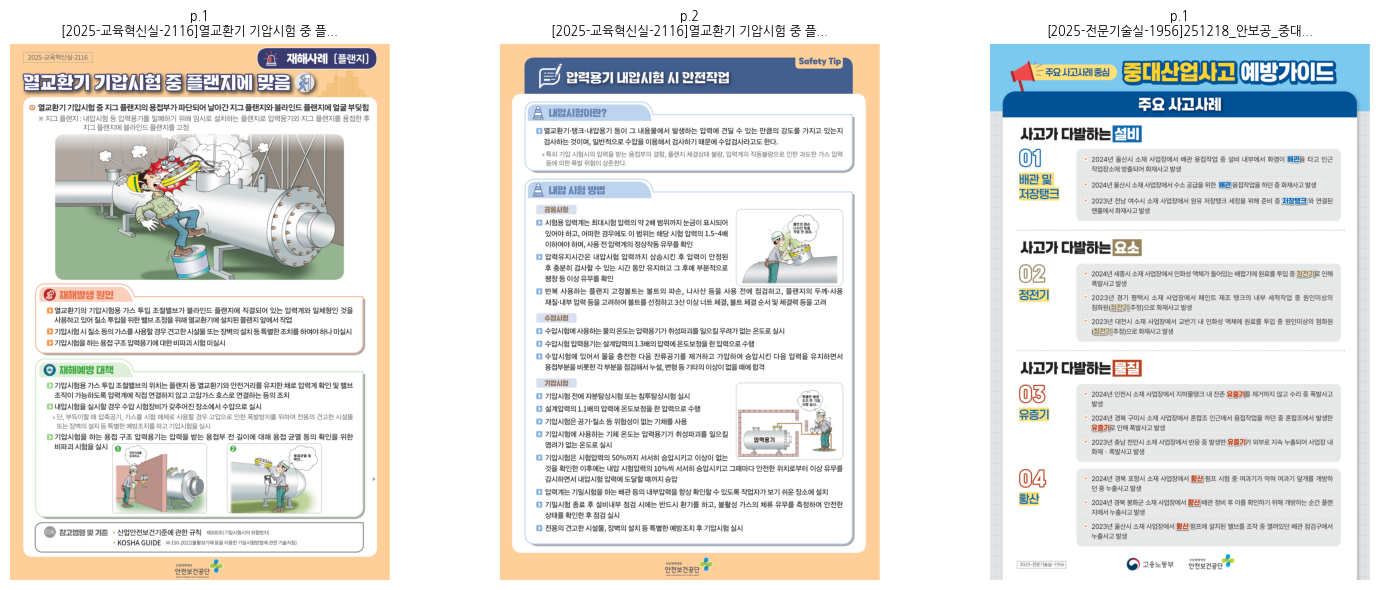

In [13]:
def preview_pages(records: list[dict], n: int = 3):
    """변환된 PDF 페이지 샘플을 matplotlib 그리드로 확인."""
    setup_korean_matplotlib()
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, rec in zip(axes, records[:n]):
        img = Image.open(rec["image_path"]).convert("RGB")
        ax.imshow(img)
        title = rec["pdf_name"][:30] + "..." if len(rec["pdf_name"]) > 30 else rec["pdf_name"]
        ax.set_title(f"p.{rec['page_num']}\n{title}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


preview_pages(manifest, n=min(3, len(manifest)))


## 3. ColPali Multi-vector 임베딩

ColPali는 PDF 페이지 이미지를 **수백~천 개의 패치 벡터**로 인코딩합니다.
질문 텍스트도 동일 공간의 Multi-vector로 변환되어 **MaxSim** 검색에 사용됩니다.

### 임베딩(Embedding)이란?

AI가 이미지·텍스트를 **숫자 배열(벡터)** 로 바꾸는 과정입니다.
의미가 비슷한 내용은 벡터 공간에서 **가까이** 위치합니다.

- 일반 검색(SigLIP2): 이미지 1장 → **벡터 1개**
- ColPali: 페이지 1장 → **벡터 약 1,000개** (Multi-vector)

### ColPali가 페이지를 어떻게 보나?

1. PDF 페이지 PNG를 입력
2. 이미지를 **32×32 = 1,024개 패치**로 나눔
3. 각 패치마다 **128차원** 벡터 생성
4. 질문도 토큰별 Multi-vector로 변환

```
페이지 이미지 ──→ [패치1 벡터, 패치2 벡터, ... 패치1024 벡터]
질문 "지게차 안전" ──→ [토큰1 벡터, 토큰2 벡터, ...]
```

### Late Interaction(MaxSim)이란?

질문 벡터와 페이지 벡터를 **1:1로 전부 비교**하는 방식입니다.
(ColBERT·ColPali 계열 모델의 핵심 아이디어)

- 질문의 각 토큰이 페이지의 **어느 패치**와 가장 잘 맞는지 찾고
- 그 점수들을 합쳐 **페이지 전체 관련도**를 계산합니다.
- 표 한 칸, 경고 박스, 제목 등 **부분적으로 관련**된 영역도 잡아낼 수 있습니다.

### 왜 OCR 대신 ColPali인가?

| 방식 | 장점 | 단점 |
|------|------|------|
| OCR + 텍스트 RAG | 구현 단순 | 표·도표·레이아웃 손실 |
| ColPali Visual RAG | 표·그림·레이아웃 유지 | GPU·용량 필요, Multi-vector DB 필요 |

KOSHA 매뉴얼처럼 **표·체크리스트·그림**이 많은 PDF에 적합합니다.


In [14]:
class ColPaliEncoder:
    """ColPali v1.3 — 이미지/텍스트 Multi-vector 임베딩."""

    def __init__(self, model_id: str = COLPALI_MODEL_ID):
        dtype = torch.bfloat16 if device == "cuda" else torch.float32
        self.model = ColPaliForRetrieval.from_pretrained(
            model_id,
            torch_dtype=dtype,
            device_map="auto" if device == "cuda" else None,
        ).eval()  # 추론 전용
        if device != "cuda":
            self.model.to(device)
        self.processor = ColPaliProcessor.from_pretrained(model_id)
        print(f"ColPali 로딩 완료: {model_id} ({device})")

    @property
    def model_device(self):
        return next(self.model.parameters()).device

    @torch.no_grad()
    def encode_images(self, images: list[Image.Image]) -> list[np.ndarray]:
        # 페이지 1장 → (패치 수, 128) Multi-vector (약 1,000 패치)
        batch = self.processor(images=images, return_tensors="pt")
        batch = {k: v.to(self.model_device) for k, v in batch.items()}
        outputs = self.model(**batch)
        embs = outputs.embeddings.detach().cpu().float().numpy()
        return [embs[i] for i in range(embs.shape[0])]

    @torch.no_grad()
    def encode_queries(self, queries: list[str]) -> list[np.ndarray]:
        # 한글 질문 → (토큰 수, 128) Multi-vector
        batch = self.processor(text=queries, return_tensors="pt")
        batch = {k: v.to(self.model_device) for k, v in batch.items()}
        outputs = self.model(**batch)
        embs = outputs.embeddings.detach().cpu().float().numpy()
        return [embs[i] for i in range(embs.shape[0])]

    def unload(self):
        # Qwen3-VL 로드 전 GPU VRAM 확보
        del self.model
        del self.processor
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print("ColPali GPU 메모리 해제 완료")


colpali_encoder = ColPaliEncoder()

# PC 다운로드(vidore--colpali-v1.3-hf,5.85G) : 약 5.5분 소요


config.json:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/423 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

ColPali 로딩 완료: vidore/colpali-v1.3-hf (cuda)


In [15]:
# 샘플 1장 임베딩 shape 확인
sample_img = Image.open(manifest[0]["image_path"]).convert("RGB")
sample_emb = colpali_encoder.encode_images([sample_img])[0]
print(f"페이지 Multi-vector shape: {sample_emb.shape}")  # (패치 수, 128)

sample_q = colpali_encoder.encode_queries(["크레인 작업 시 안전수칙"])[0]
print(f"질의 Multi-vector shape: {sample_q.shape}")
# 질의 벡터 수는 질문 길이에 따라 달라짐 (보통 20~30개 토큰)


페이지 Multi-vector shape: (1030, 128)
질의 Multi-vector shape: (23, 128)


## 4. Qdrant Multi-vector 인덱싱

Qdrant 컬렉션에 `MultiVectorComparator.MAX_SIM`을 설정해 ColPali Late Interaction을 저장합니다.
Multi-vector 특성상 HNSW는 비활성(`m=0`)하고 **brute-force MaxSim**으로 검색합니다.

### Qdrant(벡터 DB)란?

**벡터(숫자 배열)를 저장하고, 질문 벡터와 비슷한 것을 빠르게 찾는** 데이터베이스입니다.
ChromaDB(02번 노트북)와 역할은 같지만, ColPali의 **Multi-vector + MaxSim**을 네이티브 지원합니다.

```
저장: PDF 페이지 1장 = Qdrant 포인트 1개
      └── vector: [패치1, 패치2, ... ]  (약 1,000 × 128차원)
      └── payload: pdf_name, page_num, image_path ...
```

### MaxSim 설정

```python
multivector_config=MultiVectorConfig(
    comparator=MultiVectorComparator.MAX_SIM
)
```

- Qdrant가 ColPali와 동일한 **Late Interaction 점수**를 계산합니다.
- `hnsw_config m=0`: Multi-vector는 HNSW 근사 검색 대신 **전수 MaxSim** 사용
  - 소규모(수백 페이지) 실습에는 충분히 빠릅니다.
  - 수만 페이지 이상이면 mean-pooling 2단계 검색으로 확장 가능 ([Qdrant 튜토리얼](https://qdrant.tech/documentation/tutorials-search-engineering/pdf-retrieval-at-scale/))

### 싱글톤 클라이언트

> **주의**: Qdrant **로컬 모드**(`path=`)는 동일 폴더에 **클라이언트 1개만** 열 수 있습니다.
> 노트북에서는 `get_qdrant_client()` 싱글톤으로 재사용합니다.
> `AlreadyLocked` 오류 시 **Kernel → Restart** 후 처음부터 실행하세요.

### payload(메타데이터) 역할

벡터만으로는 "몇 번째 PDF 몇 페이지"인지 알 수 없습니다.
`payload`에 `pdf_name`, `page_num`, `image_path`를 함께 저장해
검색 후 **이미지 표시·Qwen3-VL 입력**에 사용합니다.


In [16]:
def close_qdrant_client():
    """Qdrant 로컬 lock 해제. 재인덱싱·재연결 전에 호출."""
    global qdrant_client
    if qdrant_client is not None:
        qdrant_client.close()
        qdrant_client = None
        print("Qdrant 클라이언트 종료")


def get_qdrant_client() -> QdrantClient:
    """Qdrant 로컬 클라이언트 싱글톤 (동일 path 중복 open 방지)."""
    global qdrant_client
    if qdrant_client is None:
        qdrant_client = QdrantClient(path=str(QDRANT_DIR))
    return qdrant_client


def ensure_colpali_collection(client: QdrantClient, recreate: bool = False):
    exists = client.collection_exists(COLLECTION_NAME)
    if exists and recreate:
        client.delete_collection(COLLECTION_NAME)
        exists = False
    if not exists:
        client.create_collection(
            collection_name=COLLECTION_NAME,
            vectors_config={
                VECTOR_NAME: models.VectorParams(
                    size=EMBED_DIM,
                    distance=models.Distance.COSINE,
                    multivector_config=models.MultiVectorConfig(
                        comparator=models.MultiVectorComparator.MAX_SIM,  # ColBERT Late Interaction
                    ),
                    hnsw_config=models.HnswConfigDiff(m=0),  # Multi-vector는 brute-force MaxSim
                )
            },
        )
        print(f"Qdrant 컬렉션 생성: {COLLECTION_NAME}")
    else:
        print(f"Qdrant 컬렉션 사용: {COLLECTION_NAME}")


def index_pages_to_qdrant(
    encoder: ColPaliEncoder,
    records: list[dict],
    batch_size: int = 2,
    recreate: bool = False,
):
    global qdrant_client

    if recreate:
        close_qdrant_client()  # REBUILD_INDEX=True 시 기존 lock·컬렉션 정리

    client = get_qdrant_client()
    ensure_colpali_collection(client, recreate=recreate)

    # 이미 인덱싱된 페이지 수가 manifest와 같으면 스킵
    if not recreate and client.count(COLLECTION_NAME).count >= len(records):
        print(f"기존 인덱스 사용: {client.count(COLLECTION_NAME).count} 포인트")
        return client

    pending = []
    for i in tqdm(range(0, len(records), batch_size), desc="Qdrant 인덱싱"):
        batch_records = records[i : i + batch_size]
        images = [Image.open(r["image_path"]).convert("RGB") for r in batch_records]
        embeddings = encoder.encode_images(images)

        for rec, emb in zip(batch_records, embeddings):
            # Qdrant point id는 UUID 형식 필요
            point_id = str(uuid.uuid5(uuid.NAMESPACE_URL, f"{rec['doc_id']}_{rec['page_num']}"))
            pending.append(
                models.PointStruct(
                    id=point_id,
                    vector={VECTOR_NAME: emb.tolist()},  # list[list[float]] Multi-vector
                    payload={
                        "doc_id": rec["doc_id"],
                        "pdf_name": rec["pdf_name"],
                        "page_num": rec["page_num"],
                        "page_total": rec["page_total"],
                        "image_path": rec["image_path"],  # 검색 후 Qwen3-VL 입력용
                    },
                )
            )

        client.upsert(collection_name=COLLECTION_NAME, points=pending)
        pending = []

    cnt = client.count(COLLECTION_NAME).count
    print(f"Qdrant 인덱싱 완료: {cnt} 페이지")
    return client


qdrant_client = index_pages_to_qdrant(
    colpali_encoder,
    manifest,
    batch_size=COLPALI_BATCH_SIZE,
    recreate=REBUILD_INDEX,
)


Qdrant 컬렉션 생성: kosha_colpali_pages


Qdrant 인덱싱:   0%|          | 0/41 [00:00<?, ?it/s]

Qdrant 인덱싱 완료: 81 페이지


## 5. 질문 → 관련 페이지 검색

한글 질문을 ColPali **질의 Multi-vector**로 변환한 뒤,
Qdrant MaxSim으로 **가장 관련 높은 PDF 페이지** Top-k를 검색합니다.

### 검색 흐름

```
"지게차 충돌 예방 조치는?"
        ↓
ColPali encode_queries()  →  질문 Multi-vector
        ↓
Qdrant query_points(MaxSim)  →  저장된 모든 페이지와 점수 비교
        ↓
Top-3 페이지 (score 높은 순)
        ↓
matplotlib으로 페이지 이미지 + pdf_name 표시
```

### score(점수) 해석

- **높을수록** 질문과 해당 PDF 페이지가 **의미적으로 더 관련** 있음
- MaxSim 점수는 0~1 고정 범위가 아닐 수 있음 → **순위(1위·2위·3위)** 비교가 중요
- 1위 페이지가 항상 완벽하지 않을 수 있으므로 Top-2~3을 Qwen3-VL에 함께 넘깁니다

### 02번 SigLIP2 검색과의 차이

| | SigLIP2 + ChromaDB (02) | ColPali + Qdrant (12) |
|--|-------------------------|------------------------|
| 입력 | CCTV 프레임 | PDF 페이지 |
| 벡터 | 1개 (768~1152차원) | ~1,000개 (128차원) |
| 유사도 | 코사인 (단일 벡터) | MaxSim (Multi-vector) |
| 강점 | 영상·한글 텍스트 검색 | 표·레이아웃·문서 구조 |

### 검색만 먼저 테스트하기

아래 셀에서 `QUERY` 문자열을 바꿔 다양한 안전 주제를 시험해 볼 수 있습니다.
Qwen3-VL 로드 전이라 **빠르게** 검색 품질만 확인할 때 유용합니다.


In [17]:
def search_kosha_pages(
    query: str,
    encoder: ColPaliEncoder,
    client: QdrantClient,
    top_k: int = TOP_K,
) -> list[dict]:
    """한글 질문 → ColPali query embedding → Qdrant MaxSim Top-k."""
    query_emb = encoder.encode_queries([query])[0]
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_emb.tolist(),
        using=VECTOR_NAME,
        limit=top_k,
        with_payload=True,
    )
    hits = []
    for rank, point in enumerate(response.points, 1):
        hits.append({
            "rank": rank,
            "score": float(point.score),  # MaxSim 점수 (높을수록 관련성 높음)
            "id": point.id,
            "payload": point.payload,
        })
    return hits


def show_search_hits(hits: list[dict]):
    """검색된 PDF 페이지 이미지 + 메타 테이블 시각화."""
    setup_korean_matplotlib()
    n = len(hits)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]
    rows = []
    for ax, hit in zip(axes, hits):
        p = hit["payload"]
        img = Image.open(p["image_path"]).convert("RGB")
        ax.imshow(img)
        pdf_short = p["pdf_name"][:28] + "..." if len(p["pdf_name"]) > 28 else p["pdf_name"]
        ax.set_title(
            f"#{hit['rank']} score={hit['score']:.3f}\n"
            f"p.{p['page_num']} / {pdf_short}",
            fontsize=9,
        )
        ax.axis("off")
        rows.append({
            "rank": hit["rank"],
            "score": round(hit["score"], 4),
            "pdf_name": p["pdf_name"],
            "page": p["page_num"],
        })
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(rows))


질문: 지게차 작업 시 충돌·전도를 예방하는 안전 조치는 무엇인가요?


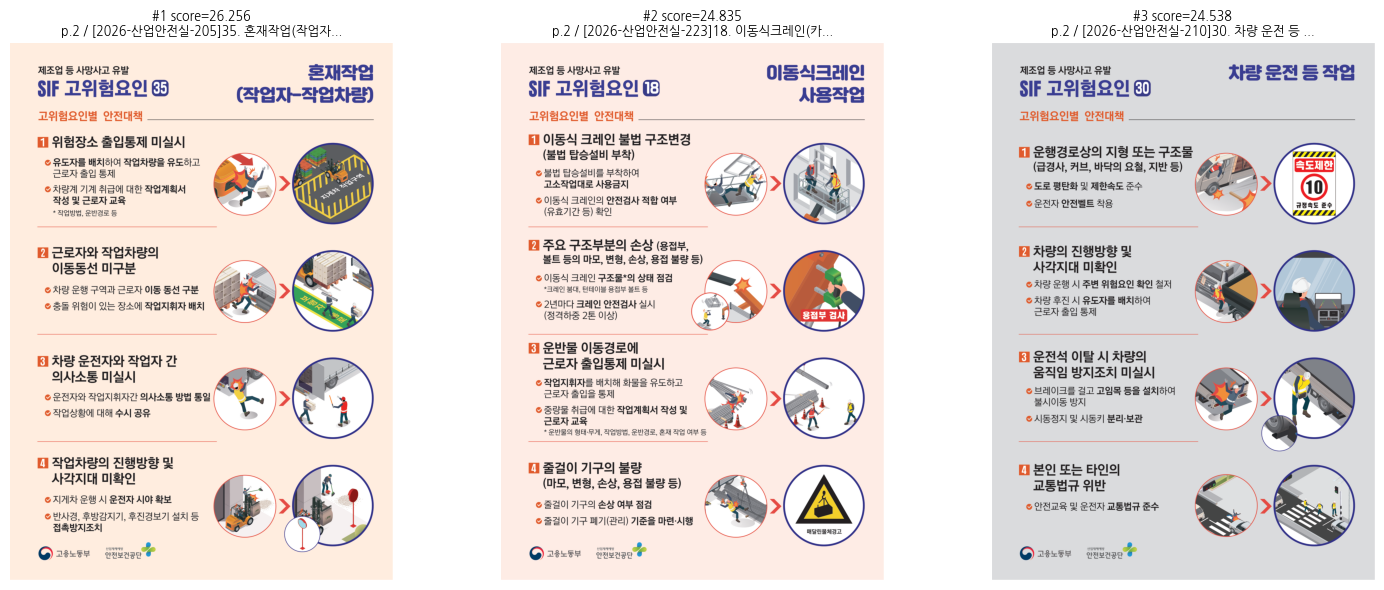

,rank,score,pdf_name,page
0,1,26.2562,[2026-산업안전실-205]35. 혼재작업(작업자-작업차량).pdf,2
1,2,24.8346,"[2026-산업안전실-223]18. 이동식크레인(카고 크레인, 집게차) 사용 작업.pdf",2
2,3,24.5376,[2026-산업안전실-210]30. 차량 운전 등 작업.pdf,2


In [18]:
QUERY = "지게차 작업 시 충돌·전도를 예방하는 안전 조치는 무엇인가요?"
print(f"질문: {QUERY}")
hits = search_kosha_pages(QUERY, colpali_encoder, qdrant_client, top_k=TOP_K)
show_search_hits(hits)


## 6. Qwen3-VL 답변 생성

검색된 페이지 이미지를 Qwen3-VL에 입력해 **문서 근거 기반 한글 답변**을 생성합니다.
VRAM 절약을 위해 ColPali 모델을 먼저 GPU에서 해제합니다.

### Qwen3-VL(Vision Language Model)이란?

**이미지 + 텍스트**를 동시에 이해하는 생성 AI입니다.
ChatGPT에 사진을 올리고 질문하는 것과 비슷하지만, **로컬 GPU**에서 실행합니다.

```
[검색된 PDF 페이지 PNG] + [질문 + "이 페이지 내용만 근거로 답하세요"]
        ↓
Qwen3-VL
        ↓
"지게차 작업 시 전방·후방 확인, 속도 제한, ..."
```

### 왜 ColPali만으로는 답변을 못 하나?

- **ColPali** = 검색 전용 (Retriever). "어느 페이지가 관련 있는지" 찾기
- **Qwen3-VL** = 생성 전용 (Generator). "그 페이지를 읽고 사람이 이해할 답" 작성

Visual RAG는 이 둘을 **역할 분리**합니다.
검색 모델은 가볍고 빠르게, 생성 모델은 정밀하게 쓰는 구조입니다.

### 2단계 답변 생성

1. **페이지별 요약** — Top-k 중 1~2장을 각각 Qwen3-VL에 넣어 2~4문장 요약
2. **종합 답변** — 요약들을 모아 5~8문장 최종 답변 생성

한 번에 여러 장을 넣으면 GPU 메모리(OOM)가 부족해질 수 있어 **1장씩** 처리합니다.

### GPU 메모리 관리

ColPali(~3B) + Qwen3-VL-2B를 **동시에** GPU에 올리면 8GB VRAM에서 OOM이 날 수 있습니다.
`colpali_encoder.unload()` → Qwen 로드 순서로 **한 번에 하나만** GPU에 올립니다.


In [19]:
# ColPali(~3B)와 Qwen3-VL(~2B) 동시 GPU 적재 시 OOM 방지
colpali_encoder.unload()
colpali_encoder = None

print(f"Qwen3-VL 로딩: {QWEN_MODEL_ID}")
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    attn_implementation="sdpa",  # Scaled Dot-Product Attention (메모리 효율)
    low_cpu_mem_usage=True,
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
print("로딩 완료.")


ColPali GPU 메모리 해제 완료
Qwen3-VL 로딩: Qwen/Qwen3-VL-2B-Instruct


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

로딩 완료.


In [20]:
def run_qwen_vl(image_paths: list[str], prompt: str, max_new_tokens: int = 256) -> str:
    """PDF 페이지 이미지 + 텍스트 프롬프트로 Qwen3-VL 추론."""
    # Windows: file:// URL 대신 PIL Image 객체 전달 (02 노트북과 동일)
    content = [{"type": "image", "image": Image.open(p).convert("RGB")} for p in image_paths]
    content.append({"type": "text", "text": prompt})
    messages = [{"role": "user", "content": content}]

    inputs = qwen_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = inputs.to(qwen_model.device)
    with torch.no_grad():
        generated = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            repetition_penalty=1.15,  # 같은 문장 반복 억제
            do_sample=False,          # greedy decoding (결정적 출력)
        )
    # 입력 토큰 제거 → 새로 생성된 부분만 디코딩
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
    text = qwen_processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
    del inputs, generated
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return text


def answer_with_kosha_pages(query: str, hits: list[dict], max_pages: int = 2) -> str:
    """검색 페이지 1~2장씩 분석 후 종합 답변."""
    per_page = []
    use_hits = hits[:max_pages]

    # 1단계: 각 검색 페이지를 개별 요약 (VRAM 절약을 위해 1장씩)
    for i, hit in enumerate(use_hits, 1):
        p = hit["payload"]
        prompt = (
            f"{query}\n\n"
            f"[출처] {p['pdf_name']} — {p['page_num']}페이지\n\n"
            "이 PDF 페이지 이미지에 보이는 안전보건 내용만 근거로 2~4문장 한국어로 요약하세요."
        )
        summary = run_qwen_vl([p["image_path"]], prompt, max_new_tokens=180)
        per_page.append(f"페이지 {i} ({p['pdf_name']} p.{p['page_num']}): {summary}")
        print(f"  페이지 {i}/{len(use_hits)} 분석 완료")

    # 2단계: 페이지별 요약을 종합해 최종 답변 생성
    best = use_hits[0]["payload"]["image_path"]  # 1순위 페이지 이미지 1장 동봉
    joined = "\n".join(per_page)
    final_prompt = (
        f"{query}\n\n[검색된 KOSHA 안전보건 문서 페이지 요약]\n{joined}\n\n"
        "위 내용을 종합해 현장에서 적용할 수 있는 안전 조치·주의사항을 5~8문장 한국어로 설명하세요. "
        "문서에 없는 내용은 추측하지 마세요."
    )
    return run_qwen_vl([best], final_prompt, max_new_tokens=320)


In [21]:
print("=" * 60)
print("[Qwen3-VL — KOSHA 안전보건 Visual RAG 답변]")
print("=" * 60)
answer = answer_with_kosha_pages(QUERY, hits, max_pages=2)
display(Markdown(answer))

# RTX 3060 : 약 1분 소요


[Qwen3-VL — KOSHA 안전보건 Visual RAG 답변]
  페이지 1/2 분석 완료
  페이지 2/2 분석 완료


현장에서 지게차 작업 시 충돌 및 전도를 방지하기 위해 다음과 같은 안전 조치를 취해야 합니다. 먼저, 작업 차량을 유도하고 근로자를 출입 통제된 공간에 위치시키는 것이 중요하며, 작업자와 근로자의 교육을 실시해야 합니다. 또한, 근로자와 작업차량 사이의 이동 동선은 차량 운행 구역과 근로자 이동 동선을 분리하여, 충돌 위험이 있는 장소에 작업지휘자에게 배치되어야 합니다. 작업자와 작업차량 간의 의사소통은 운전자와 작업지휘자 간의 의사소통 방법을 통해 이루어지고, 작업 상황에 대해 수시 공유해야 합니다. 이동식크레인이 사용될 경우, 그 구조 변경이나 주요 부분의 손상 등을 확인하고, 운반물의 출입 통제를 위한 점검을 수행해야 하며, 전기와 물리적 충돌 위험을 줄이기 위해 매달린 물체 경고등을 설치해야 합니다. 이러한 조치들은 지게차 작업 시 발생할 수 있는 위험을 최소화하고, 작업자의 안전을 보장하는 중요한 요소입니다.

## 7. Visual RAG 통합 파이프라인

질문 하나로 **ColPali 검색 → Qwen3-VL 답변**까지 end-to-end 실행합니다.
`visual_rag_kosha()` 함수 하나로 전체 과정을 묶습니다.

### 함수 동작 순서

```
visual_rag_kosha("전기설비 감전 예방은?")
    │
    ├─ 1. ColPali 로드 (없으면)
    ├─ 2. Qdrant에서 Top-k 페이지 검색 + 이미지 표시
    ├─ 3. ColPali GPU 해제
    ├─ 4. Qwen3-VL 로드 (없으면)
    └─ 5. 검색 페이지 기반 한글 답변 생성·출력
```

### run_vlm=False 옵션

```python
visual_rag_kosha("질문", run_vlm=False)
```

- 검색·시각화만 하고 **Qwen3-VL 답변은 생략**
- ColPali·Qdrant만 빠르게 테스트할 때 사용

### EXTRA_QUERIES (10개 예시)

아래 셀에 KOSHA PDF 40종 주제와 맞춘 **질의 10개**가 준비되어 있습니다.
`EXTRA_QUERIES[:]`로 바꾸면 10개를 연속 실행합니다 (GPU·시간 여유 필요).

| # | 질의 주제 | 관련 PDF |
|---|-----------|----------|
| 1 | 전기설비 감전 | 전기설비 취급 |
| 2 | 위험물질 보호구 | 위험물질 취급 |
| 3 | 지게차 충돌·전도 | 지게차 사용 |
| ... | ... | ... |


In [22]:
def visual_rag_kosha(
    query: str,
    top_k: int = TOP_K,
    run_vlm: bool = True,
) -> dict:
    """
    Visual RAG end-to-end: ColPali 검색 → (선택) Qwen3-VL 답변.
    run_vlm=False면 검색 결과만 반환.
    """
    global colpali_encoder, qwen_model, qwen_processor, qdrant_client

    # ColPali는 필요할 때만 로드 (Qwen 실행 후 None 상태일 수 있음)
    if colpali_encoder is None:
        colpali_encoder = ColPaliEncoder()

    hits = search_kosha_pages(query, colpali_encoder, get_qdrant_client(), top_k=top_k)
    show_search_hits(hits)

    result = {"query": query, "hits": hits, "answer": None}
    if not run_vlm:
        return result

    colpali_encoder.unload()
    colpali_encoder = None

    # Qwen은 최초 1회만 로드, 이후 질의에서는 재사용
    if "qwen_model" not in globals() or qwen_model is None:
        qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
            QWEN_MODEL_ID,
            torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
            device_map="auto" if device == "cuda" else None,
            attn_implementation="sdpa",
            low_cpu_mem_usage=True,
        )
        qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)

    result["answer"] = answer_with_kosha_pages(query, hits, max_pages=2)
    display(Markdown(result["answer"]))
    return result



질문: 전기설비 점검·충전 작업 시 감전 예방 조치는?


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

ColPali 로딩 완료: vidore/colpali-v1.3-hf (cuda)


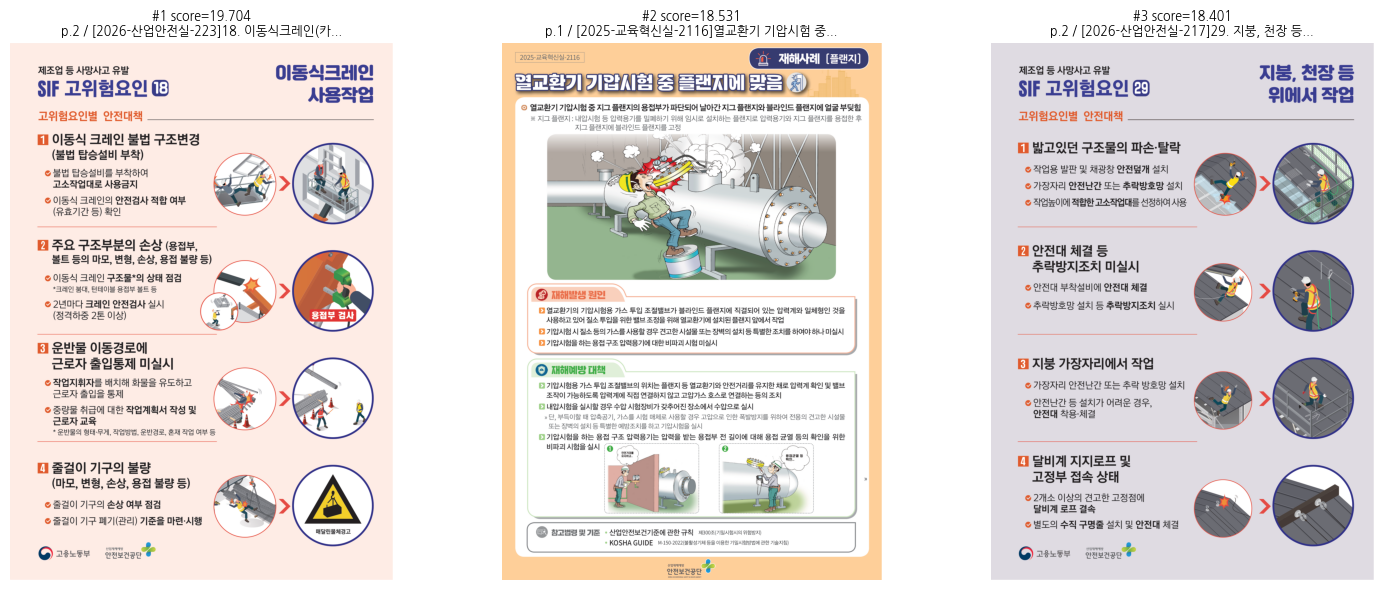

,rank,score,pdf_name,page
0,1,19.7039,"[2026-산업안전실-223]18. 이동식크레인(카고 크레인, 집게차) 사용 작업.pdf",2
1,2,18.5314,[2025-교육혁신실-2116]열교환기 기압시험 중 플랜지에 맞음(웹용).pdf,1
2,3,18.4008,"[2026-산업안전실-217]29. 지붕, 천장 등 위에서 작업.pdf",2


ColPali GPU 메모리 해제 완료
  페이지 1/2 분석 완료
  페이지 2/2 분석 완료


이동식크레인을 사용할 때는 전기설비의 점검과 충전 작업을 수행하기 전에 전기를 끄거나 전원을 차단해야 하며, 전기 장비를 점검하고 충전하는 과정에서 전기적 부하가 발생하지 않도록 해야 합니다. 이동식크레인은 전기 설비와 함께 작동하므로, 전기 장비의 점검 및 유지 관리를 통해 전기 장비의 상태를 확인해야 하고, 전원을 다시 켜야 할 경우에는 전기 장비의 상태를 확인하여 정확한 점검을 실시해야 합니다. 전기 설비의 점검 후 전원을 다시 켜야 할 경우, 전기 장비의 상태를 확인하여 정확하게 점검을 진행해야 합니다. 전기 설비의 점검 및 충전 작업 시에는 반드시 전기 장비를 끄고, 접촉을 방지하기 위해 전기 회로를 차단해야 하며, 전기 장비와 연결된 부분을 철저히 확인하고, 전원을 끊거나 단절 처리하여 위험을 줄여야 합니다. 작업 중에는 전기 장비를 직접 만지면 안되고, 가능한 한 다른 사람에게도 알려주는 것이 중요합니다. 이동식크레인을 운용할 때는 전기 설비의 점검과 유지 관리가


질문: 위험물질 취급 시 필요한 보호구와 환기·누출 대응 기준은?


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

ColPali 로딩 완료: vidore/colpali-v1.3-hf (cuda)


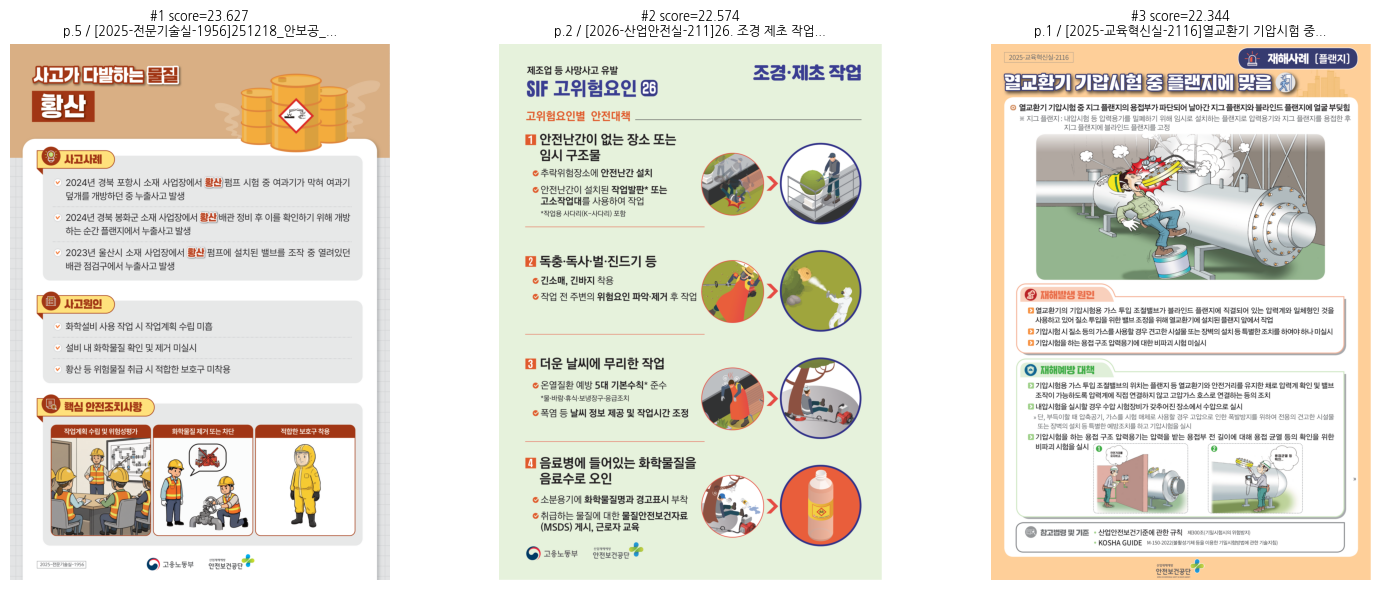

,rank,score,pdf_name,page
0,1,23.6268,[2025-전문기술실-1956]251218_안보공_중대산업사고 예방 가이드 (2).pdf,5
1,2,22.5736,[2026-산업안전실-211]26. 조경 제초 작업.pdf,2
2,3,22.3436,[2025-교육혁신실-2116]열교환기 기압시험 중 플랜지에 맞음(웹용).pdf,1


ColPali GPU 메모리 해제 완료
  페이지 1/2 분석 완료
  페이지 2/2 분석 완료


이미지와 문서 내용을 바탕으로, 황산 등의 위험물질 취급 시 필요한 보호구와 환기·누출 대응 기준을 다음과 같이 설명합니다:

1. **보호구**: 황산은 강한 산성 물질로, 작업 중에는 황산용 방수복이나 유리형 보호복 등을 착용해야 하며, 이는 피부와 눈에 직접적으로 영향을 미칠 수 있기 때문입니다.
   
2. **환기**: 화학설비 사용 시에는 작업 계획 수립 후 위험성 평가를 거쳐, 환기를 통해 공기 순환을 유지해야 합니다. 이는 황산의 냄새나 독성을 외부로 배출하기 위한 중요한 단계입니다.

3. **누출 대응**: 누출 발생 시에는 즉각적인 대응이 필요하며, 황산의 특징인 강한 산성 성질을 고려하여, 가능한 한 빠르게 흡입되지 않도록 하는 것이 중요합니다. 이때는 황산 용액을 담당하는 사람에게만 해당되는 사항이지만, 일반적으로는 급속도로 처리해야 합니다.

4. **작업 관리**: 화학설비 사용 시에는 작업계획 수립과 위험성 평가를 실시해야 하며, 이러한 과정에서 모든 직원들이 책임감 있게


질문: 지게차 사용 작업 시 충돌·전도·추락을 예방하는 안전 조치는?


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

ColPali 로딩 완료: vidore/colpali-v1.3-hf (cuda)


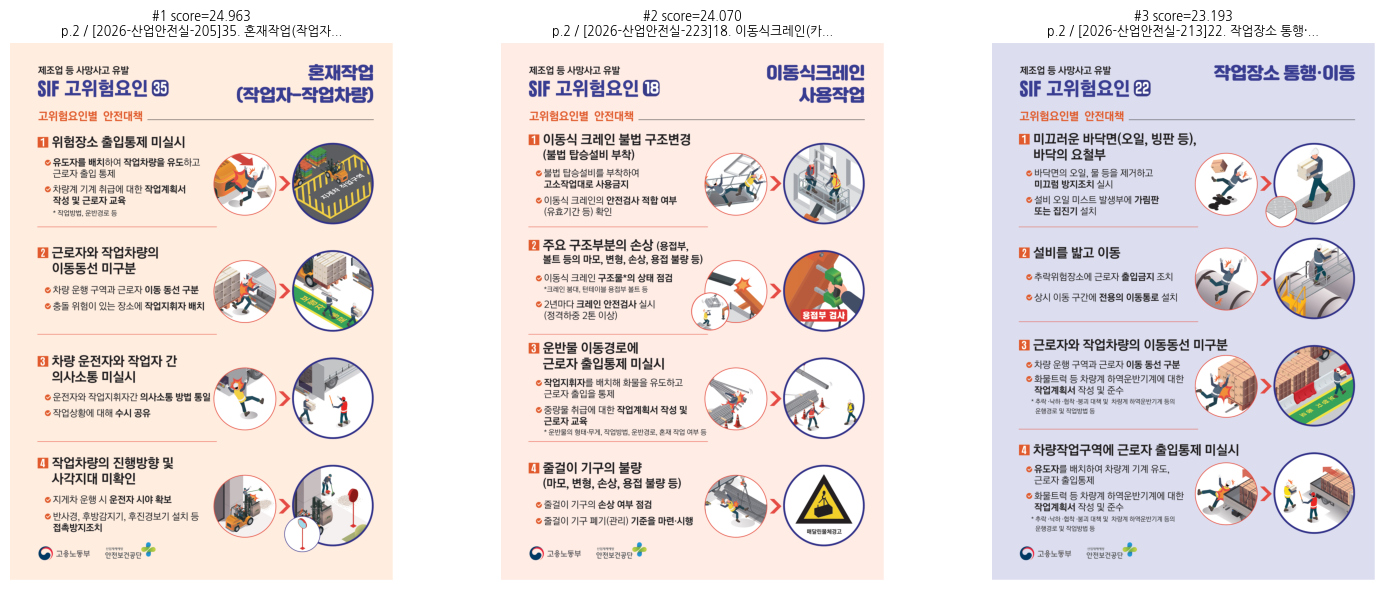

,rank,score,pdf_name,page
0,1,24.9626,[2026-산업안전실-205]35. 혼재작업(작업자-작업차량).pdf,2
1,2,24.0700,"[2026-산업안전실-223]18. 이동식크레인(카고 크레인, 집게차) 사용 작업.pdf",2
2,3,23.1933,[2026-산업안전실-213]22. 작업장소 통행·이동.pdf,2


ColPali GPU 메모리 해제 완료
  페이지 1/2 분석 완료
  페이지 2/2 분석 완료


현장에서 지게차를 사용하는 작업 시에는 반드시 유도자를 배치하여 작업차량을 유도하고 근로자가 출입 통제되어야 한다. 이는 충돌 및 전도 위험을 줄이는 핵심 조치이며, 작업계획서와 교육이 필수적인 점을 기억해야 한다. 근로자의 이동 동선과 작업차량의 위치를 정확하게 파악하고, 충돌 위험이 있는 장소에서는 작업지휘자만을 배치해야 한다. 작업자와 작업차량 사이의 의사소통 방식을 명확히 하고, 이를 통해 일관된 안전 관리가 가능하다. 작업 중에는 지게차 운행 시 운전자 시야 확보와 반사광, 후방감지기, 후진경보기 설치 등을 통해 보다 안정적인 작업 환경을 유지한다. 이러한 조치들은 사고 예방을 위한 기본적인 안전 대책이다.

In [23]:
# 추가 질의 예시 (KOSHA PDF 주제별 10개)
EXTRA_QUERIES = [
    "전기설비 점검·충전 작업 시 감전 예방 조치는?",                          # 23. 전기설비 취급 작업
    "위험물질 취급 시 필요한 보호구와 환기·누출 대응 기준은?",                  # 17. 위험물질 취급
    "지게차 사용 작업 시 충돌·전도·추락을 예방하는 안전 조치는?",               # 28. 지게차 사용 작업
    "크레인(천장주행·갠트리·지브) 사용 시 중량물 낙하 예방 수칙은?",             # 32. 크레인 사용 작업
    "피트·맨홀·오폐수 처리시설 등 밀폐공간 작업 시 산소결핍 예방 조치는?",        # 34. 밀폐장소 작업
    "고소작업대 사용 시 추락 방지를 위한 안전점검·작업 수칙은?",                # 3. 고소작업대 사용 작업
    "용접·용단·도장 작업 시 화재·폭발 및 유해가스 노출 예방 방법은?",           # 14. 용접·절단·도장 작업
    "산업용로봇(자동화설비) 작업 시 협착·끼임 위험 예방 조치는?",               # 21. 자동화설비 작업
    "컨베이어 벨트 작업 시 끼임·협착 사고 예방 수칙은?",                       # 키메시지 1호_컨베이어
    "중량물 취급·운반 작업 시 낙하·요통 예방을 위한 안전 조치는?",              # 27. 중량물 취급·운반
]

for q in EXTRA_QUERIES[:3] :  # 데모: 3개만 실행 (전체 10개는 [:] 로 변경)
    print("\n" + "=" * 60)
    print(f"질문: {q}")
    visual_rag_kosha(q, top_k=TOP_K, run_vlm=True)

# RTX 3060 : 3개 질의시 약 3분 소요(10개:약 10분)

## 8. 정리

| 단계 | 기술 | 산출물 |
|------|------|--------|
| PDF 수집 | KOSHA ZIP | `data/kosha/pdfs/` |
| 페이지 렌더 | PyMuPDF | `data/kosha/pages/` |
| 임베딩 | ColPali Multi-vector | Qdrant 포인트 |
| 검색 | Qdrant MaxSim | Top-k 페이지 |
| 생성 | Qwen3-VL | 한글 안전 답변 |

### 핵심 개념 복습

| 용어 | 한 줄 설명 |
|------|-----------|
| **Visual RAG** | 이미지(PDF 페이지)를 검색하고 AI가 답변하는 RAG |
| **Multi-vector** | 문서 1장을 수백~천 개 벡터로 표현 |
| **MaxSim** | 질문·문서 토큰을 쌍별로 비교하는 Late Interaction 점수 |
| **payload** | 벡터 DB에 함께 저장하는 PDF 이름·페이지 번호 등 메타 |
| **Retriever / Generator** | ColPali(검색) + Qwen3-VL(생성) 역할 분리 |

### 자주 겪는 문제

| 증상 | 원인 | 해결 |
|------|------|------|
| PDF 파일명 깨짐 | ZIP CP949 인코딩 | 섹션 1 셀 재실행 (자동 재추출) |
| `AlreadyLocked` | Qdrant 클라이언트 중복 | Kernel Restart 후 순서대로 실행 |
| CUDA OOM | ColPali+Qwen 동시 로드 | `COLPALI_BATCH_SIZE=1`, ColPali unload 확인 |
| 검색 결과 부정확 | 인덱싱 페이지 수 부족 | `DEMO_MODE=False`, `MAX_PAGES_PER_PDF=None` |

**확장 아이디어**
- Qdrant [mean-pooling 2단계 검색](https://qdrant.tech/documentation/tutorials-search-engineering/pdf-retrieval-at-scale/)으로 대규모 확장
- Streamlit/FastAPI로 현장 안전 매뉴얼 Q&A 서비스화 (`04`, `09` 노트북 참고)
